# El Ciclo de Aprendizaje de una Red Neuronal

**Objetivo:** Entender cómo una red neuronal aprende, recorriendo el ciclo completo:

$$\text{Forward Propagation} \rightarrow \text{Loss} \rightarrow \text{Backpropagation} \rightarrow \text{Optimización} \rightarrow \text{(repetir)}$$

**Enfoque:**
- Teoría y fórmulas clave como protagonistas
- Código solo donde ayude a visualizar o consolidar
- Un training loop completo al final (NumPy + TensorFlow)

---

# Parte 1 — Forward Propagation

El forward pass es el camino que recorre un dato desde la entrada hasta la predicción final. Cada neurona en ese camino hace dos cosas:

1. **Combinación lineal:** pondera sus entradas
2. **Activación:** transforma el resultado con una función no lineal

---

## 1.1 El cálculo de una neurona

Una neurona recibe un vector de entradas $\mathbf{x}$ y calcula:

$$z = \mathbf{w} \cdot \mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b$$

Donde:
- $\mathbf{w}$ son los **pesos** — determinan la importancia de cada entrada
- $b$ es el **bias** — permite un desplazamiento independiente de las entradas
- $z$ es la **pre-activación** — el resultado antes de pasar por la función de activación

Luego, la salida final de la neurona es:

$$a = f(z)$$

Donde $f$ es la **función de activación**. Sin esta función, toda la red sería equivalente a una sola transformación lineal, sin importar cuántas capas tenga.

---

## 1.2 Funciones de Activación

### ¿Por qué se necesitan?

La composición de funciones lineales es otra función lineal:

$$f_2(f_1(\mathbf{x})) = \mathbf{W}_2(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = \mathbf{W}' \mathbf{x} + \mathbf{b}'$$

Es decir, sin activaciones, una red de 100 capas no es más poderosa que una de 1 capa. Las funciones de activación **rompen la linealidad** y le dan a la red la capacidad de aprender relaciones complejas.

### Tipos principales

| Función | Fórmula | Rango | Cuándo usarla |
|---------|---------|-------|---------------|
| **Sigmoid** | $\sigma(z) = \frac{1}{1 + e^{-z}}$ | $(0, 1)$ | Salida de clasificación binaria |
| **Tanh** | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1, 1)$ | Capas ocultas (centrada en 0) |
| **ReLU** | $\text{ReLU}(z) = \max(0, z)$ | $[0, \infty)$ | Capas ocultas (la más común) |
| **Leaky ReLU** | $\max(\alpha z, z)$ con $\alpha = 0.01$ | $(-\infty, \infty)$ | Evitar neuronas "muertas" |
| **Softmax** | $\frac{e^{z_i}}{\sum_j e^{z_j}}$ | $(0, 1)$, suma = 1 | Salida de clasificación multiclase |

### Características clave de cada una

**Sigmoid:** Comprime cualquier valor al rango (0, 1), lo que la hace ideal para interpretar la salida como una probabilidad. Su problema: en valores muy grandes o muy pequeños de $z$, la derivada se acerca a cero (gradientes que se desvanecen).

**Tanh:** Similar a sigmoid pero centrada en cero, lo que generalmente ayuda a que el entrenamiento converja más rápido. Tiene el mismo problema de gradientes que se desvanecen en los extremos.

**ReLU:** Extremadamente simple y eficiente. No sufre de vanishing gradient para valores positivos. Su debilidad: si una neurona recibe solo valores negativos, su gradiente es permanentemente cero y deja de aprender ("neurona muerta").

**Leaky ReLU:** Resuelve el problema de las neuronas muertas al permitir un gradiente pequeño ($\alpha$) para valores negativos.

**Softmax:** No se aplica a una neurona individual sino a toda la capa de salida. Convierte un vector de valores arbitrarios en una distribución de probabilidad.

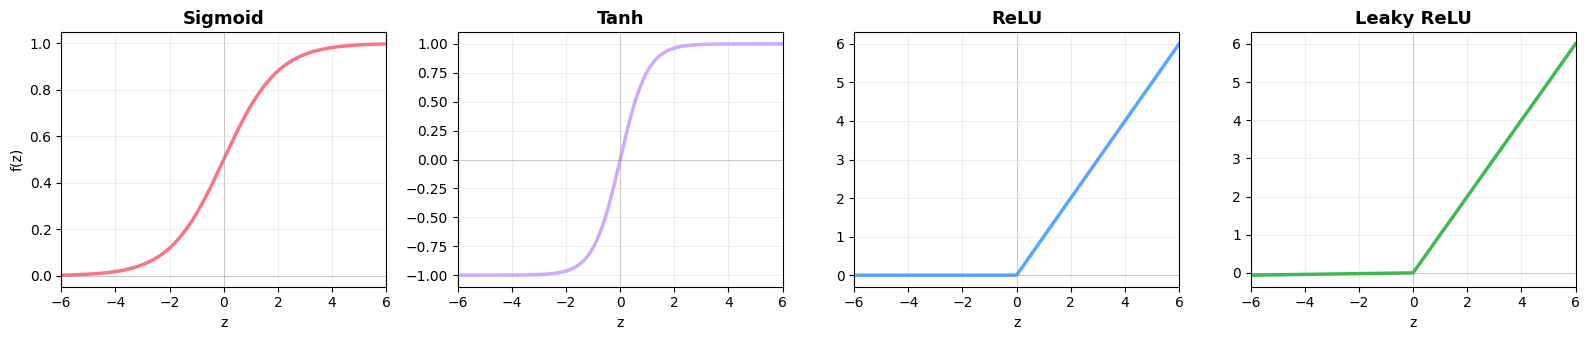

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Visualización de las funciones de activación ---

z = np.linspace(-6, 6, 300)

sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)
leaky_relu = np.where(z > 0, z, 0.01 * z)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

activaciones = [
    ("Sigmoid", sigmoid, "#F97583"),
    ("Tanh", tanh, "#D2A8FF"),
    ("ReLU", relu, "#58A6FF"),
    ("Leaky ReLU", leaky_relu, "#3FB950"),
]

for ax, (nombre, y, color) in zip(axes, activaciones):
    ax.plot(z, y, color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_title(nombre, fontsize=13, fontweight='bold')
    ax.set_xlabel('z')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-6, 6)

axes[0].set_ylabel('f(z)')
plt.tight_layout()
plt.show()

### ¿Cuál usar?

En la práctica, la elección estándar moderna es:

- **Capas ocultas:** ReLU (o Leaky ReLU si encuentras neuronas muertas)
- **Salida binaria:** Sigmoid
- **Salida multiclase:** Softmax
- **Tanh:** en arquitecturas específicas como LSTMs

No es necesario memorizar esto — lo importante es entender **por qué** existen (romper linealidad) y que la derivada de cada una jugará un papel crucial en el backpropagation.

---

## 1.3 De neuronas a capas

Cuando agrupamos $m$ neuronas que reciben las mismas $n$ entradas, el forward pass de toda la capa se calcula como una operación matricial:

$$\mathbf{Z} = \mathbf{X} \cdot \mathbf{W}^T + \mathbf{b}$$
$$\mathbf{A} = f(\mathbf{Z})$$

Donde:
- $\mathbf{X}$ es el batch de datos con dimensión $(B, n)$ — $B$ muestras, $n$ features
- $\mathbf{W}$ es la matriz de pesos $(m, n)$ — una fila por neurona
- $\mathbf{b}$ es el vector de biases $(m,)$
- $\mathbf{Z}$ es la pre-activación $(B, m)$
- $\mathbf{A}$ es la salida activada $(B, m)$ — que se convierte en la entrada de la siguiente capa

La razón de usar matrices es puramente práctica: las GPUs están optimizadas para este tipo de operaciones, y nos permite calcular todas las neuronas y todas las muestras de un solo golpe.

---

## 1.4 El flujo completo: red de múltiples capas

En una red con $L$ capas, el forward pass es simplemente encadenar estas operaciones:

$$\mathbf{Z}^{[1]} = \mathbf{X} \cdot \mathbf{W}^{[1]T} + \mathbf{b}^{[1]} \quad \rightarrow \quad \mathbf{A}^{[1]} = f^{[1]}(\mathbf{Z}^{[1]})$$

$$\mathbf{Z}^{[2]} = \mathbf{A}^{[1]} \cdot \mathbf{W}^{[2]T} + \mathbf{b}^{[2]} \quad \rightarrow \quad \mathbf{A}^{[2]} = f^{[2]}(\mathbf{Z}^{[2]})$$

$$\vdots$$

$$\mathbf{Z}^{[L]} = \mathbf{A}^{[L-1]} \cdot \mathbf{W}^{[L]T} + \mathbf{b}^{[L]} \quad \rightarrow \quad \hat{\mathbf{y}} = f^{[L]}(\mathbf{Z}^{[L]})$$

La salida $\hat{\mathbf{y}}$ es la **predicción** de la red. Ahora necesitamos saber qué tan lejos estuvo de la realidad.

---

# Parte 2 — Funciones de Pérdida (Loss)

La función de pérdida cuantifica **qué tan mal** estuvo la predicción $\hat{y}$ comparada con el valor real $y$. Es un número escalar: mientras más alto, peor la predicción.

El objetivo del entrenamiento es **minimizar** este valor ajustando los pesos y biases.

---

## 2.1 Para regresión: Error Cuadrático Medio (MSE)

Cuando la salida es un valor continuo (predecir un precio, una temperatura, etc.):

$$\mathcal{L}_{MSE} = \frac{1}{B} \sum_{i=1}^{B} (y_i - \hat{y}_i)^2$$

**¿Por qué se eleva al cuadrado?**
- Penaliza errores grandes mucho más que errores pequeños (un error de 10 "duele" 100 veces más que un error de 1)
- Elimina el signo: un error de +5 y uno de -5 son igualmente malos
- Es diferenciable en todos los puntos, lo que facilita calcular gradientes

---

## 2.2 Para clasificación binaria: Binary Cross-Entropy

Cuando la salida es una probabilidad entre 0 y 1 (sigmoid):

$$\mathcal{L}_{BCE} = -\frac{1}{B} \sum_{i=1}^{B} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

**Intuición:** Si la etiqueta real es $y = 1$, solo el término $\log(\hat{y})$ sobrevive. Si la red predice $\hat{y} = 0.99$, el loss es pequeño ($-\log(0.99) \approx 0.01$). Si predice $\hat{y} = 0.01$, el loss es enorme ($-\log(0.01) \approx 4.6$). La penalización crece exponencialmente cuando la predicción es confiadamente incorrecta.

---

## 2.3 Para clasificación multiclase: Categorical Cross-Entropy

Cuando la salida es una distribución de probabilidad sobre $C$ clases (softmax):

$$\mathcal{L}_{CCE} = -\frac{1}{B} \sum_{i=1}^{B} \sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})$$

En la práctica, si usamos one-hot encoding, solo la clase correcta contribuye al loss (todos los demás $y_{i,c} = 0$), por lo que se simplifica a:

$$\mathcal{L} = -\frac{1}{B} \sum_{i=1}^{B} \log(\hat{y}_{i, c^*})$$

Donde $c^*$ es la clase correcta. El loss solo mide: **¿qué probabilidad le asignaste a la respuesta correcta?**

### Resumen rápido

| Tipo de problema | Activación de salida | Función de pérdida |
|:---:|:---:|:---:|
| Regresión | Lineal (ninguna) | MSE |
| Clasificación binaria | Sigmoid | Binary Cross-Entropy |
| Clasificación multiclase | Softmax | Categorical Cross-Entropy |

Ahora que tenemos un número que mide el error, necesitamos averiguar **cómo ajustar cada peso para reducirlo**. Eso es el backpropagation.

---

# Parte 3 — Backpropagation

Backpropagation responde la pregunta: **¿cuánto contribuyó cada peso al error?**

Para responderla, necesitamos calcular la **derivada parcial** del loss con respecto a cada peso de la red. Si sabemos que el peso $w$ causó mucho del error, lo ajustamos mucho; si casi no contribuyó, lo ajustamos poco.

---

## 3.1 La regla de la cadena: el motor del backprop

Imaginemos una red de una sola capa con una neurona:

$$z = wx + b \quad \rightarrow \quad a = f(z) \quad \rightarrow \quad \mathcal{L} = \text{loss}(a, y)$$

Queremos calcular $\frac{\partial \mathcal{L}}{\partial w}$: ¿cuánto cambia el loss si movemos $w$ un poquito?

Como $w$ no aparece directamente en $\mathcal{L}$ sino que influye a través de una cadena ($w \rightarrow z \rightarrow a \rightarrow \mathcal{L}$), aplicamos la **regla de la cadena**:

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}$$

Cada factor tiene un significado claro:

| Factor | Significado | Depende de |
|:---:|:---|:---|
| $\frac{\partial \mathcal{L}}{\partial a}$ | ¿Qué tan sensible es el loss a la predicción? | La función de pérdida |
| $\frac{\partial a}{\partial z}$ | ¿Qué tan sensible es la activación a su entrada? | La función de activación (su derivada) |
| $\frac{\partial z}{\partial w}$ | ¿Qué tan sensible es $z$ al peso? | La entrada $x$ (ya que $z = wx + b$, entonces $\frac{\partial z}{\partial w} = x$) |

Y para el bias:

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{\partial \mathcal{L}}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial b}$$

Donde $\frac{\partial z}{\partial b} = 1$ (ya que $z = wx + b$).

---

## 3.2 Propagando hacia atrás en múltiples capas

En una red con $L$ capas, el gradiente se propaga desde la salida hacia la entrada, capa por capa. Para cada capa $l$:

**Paso 1 — Gradiente del loss respecto a la pre-activación:**

$$\boldsymbol{\delta}^{[l]} = \frac{\partial \mathcal{L}}{\partial \mathbf{Z}^{[l]}}$$

Para la **última capa** ($l = L$), esto viene directamente de la derivada del loss combinada con la activación. Por ejemplo, con softmax + cross-entropy o sigmoid + BCE, el resultado se simplifica elegantemente a:

$$\boldsymbol{\delta}^{[L]} = \hat{\mathbf{y}} - \mathbf{y}$$

Para **capas anteriores**, el gradiente se propaga hacia atrás:

$$\boldsymbol{\delta}^{[l]} = (\boldsymbol{\delta}^{[l+1]} \cdot \mathbf{W}^{[l+1]}) \odot f'^{[l]}(\mathbf{Z}^{[l]})$$

Donde $\odot$ es la multiplicación elemento a elemento y $f'$ es la derivada de la función de activación.

**Paso 2 — Gradientes de pesos y biases:**

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[l]}} = \frac{1}{B} \boldsymbol{\delta}^{[l]T} \cdot \mathbf{A}^{[l-1]}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[l]}} = \frac{1}{B} \sum_{i=1}^{B} \boldsymbol{\delta}^{[l]}_i$$

---

# Parte 4 — Optimizadores

El optimizador toma los gradientes calculados por backprop y decide **cómo y cuánto mover cada peso** para reducir el loss.

---

## 4.1 Gradient Descent (SGD)

La idea más simple: mover cada peso en la dirección opuesta al gradiente.

$$\mathbf{W} \leftarrow \mathbf{W} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{W}}$$

Donde $\eta$ es el **learning rate** — qué tan grande es cada paso.

- $\eta$ muy grande → los pasos son demasiado bruscos, el loss oscila y puede diverger
- $\eta$ muy pequeño → converge lentamente, puede quedarse atrapado en mínimos locales

En la práctica, "SGD" generalmente se refiere a **Stochastic** Gradient Descent: en vez de calcular el gradiente sobre todo el dataset, se calcula sobre mini-batches (subconjuntos) aleatorios, lo que añade ruido que puede ayudar a escapar de mínimos locales.

---

## 4.2 SGD con Momentum

El problema de SGD básico: puede oscilar mucho en zonas con pendientes muy diferentes en distintas direcciones (como un valle estrecho).

Momentum agrega "inercia" al movimiento, acumulando los gradientes anteriores:

$$\mathbf{v} \leftarrow \beta \mathbf{v} + (1 - \beta) \frac{\partial \mathcal{L}}{\partial \mathbf{W}}$$
$$\mathbf{W} \leftarrow \mathbf{W} - \eta \mathbf{v}$$

Donde $\beta$ (típicamente 0.9) controla cuánta "memoria" tiene. Es como una bola rodando cuesta abajo: si los gradientes apuntan consistentemente en la misma dirección, la velocidad aumenta; si oscilan, se cancelan.

---

## 4.3 Adam (Adaptive Moment Estimation)

Adam combina dos ideas: momentum (promedios de gradientes) + escalado adaptativo (promedios de gradientes al cuadrado):

$$\mathbf{m} \leftarrow \beta_1 \mathbf{m} + (1 - \beta_1) \frac{\partial \mathcal{L}}{\partial \mathbf{W}} \qquad \text{(primer momento: dirección)}$$

$$\mathbf{v} \leftarrow \beta_2 \mathbf{v} + (1 - \beta_2) \left(\frac{\partial \mathcal{L}}{\partial \mathbf{W}}\right)^2 \qquad \text{(segundo momento: magnitud)}$$

$$\hat{\mathbf{m}} = \frac{\mathbf{m}}{1 - \beta_1^t}, \quad \hat{\mathbf{v}} = \frac{\mathbf{v}}{1 - \beta_2^t} \qquad \text{(corrección de sesgo)}$$

$$\mathbf{W} \leftarrow \mathbf{W} - \eta \frac{\hat{\mathbf{m}}}{\sqrt{\hat{\mathbf{v}}} + \epsilon}$$

Hiperparámetros típicos: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$

**¿Por qué Adam es tan popular?**
- El learning rate se adapta automáticamente para cada peso
- Parámetros que reciben gradientes grandes → pasos más pequeños (no se desborda)
- Parámetros que reciben gradientes pequeños → pasos más grandes (no se estanca)
- Generalmente funciona bien con los hiperparámetros por defecto

### ¿Cuál usar?

| Optimizador | Ventaja | Cuándo usarlo |
|:---:|:---|:---|
| SGD + Momentum | Mejor generalización a largo plazo | Cuando puedes afinar el learning rate |
| Adam | Converge rápido, poco que afinar | Default para la mayoría de los casos |

---

# Cierre — Training Loop completo

Ahora juntemos todo en un ejemplo real: una red neuronal de 2 capas que clasifica datos de Iris (3 clases).

El flujo en cada iteración (epoch):
1. **Forward:** dato → capas → predicción
2. **Loss:** comparar predicción con realidad
3. **Backward:** calcular gradientes
4. **Update:** ajustar pesos con el optimizador

---

## Implementación desde cero con NumPy

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FUNCIONES DE ACTIVACIÓN Y SUS DERIVADAS
# ============================================================
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # estabilidad numérica
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ============================================================
# FUNCIÓN DE PÉRDIDA: Categorical Cross-Entropy
# ============================================================
def cross_entropy(y_pred, y_true):
    """y_true: one-hot (B, C), y_pred: probabilidades (B, C)"""
    eps = 1e-8  # evitar log(0)
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

In [3]:
# ============================================================
# DATOS: Iris dataset (cargado manualmente para no depender de sklearn)
# ============================================================
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data.astype(np.float64)     # (150, 4)
y = iris.target                       # (150,) con valores 0, 1, 2

# Normalizar features (importante para que los gradientes fluyan bien)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# One-hot encoding del target
y_onehot = np.zeros((len(y), 3))
y_onehot[np.arange(len(y)), y] = 1.0

# Shuffle y split simple
np.random.seed(42)
idx = np.random.permutation(len(X))
X, y_onehot = X[idx], y_onehot[idx]

X_train, X_test = X[:120], X[120:]
y_train, y_test = y_onehot[:120], y_onehot[120:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {iris.feature_names}")
print(f"Clases: {iris.target_names}")

Train: (120, 4), Test: (30, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases: ['setosa' 'versicolor' 'virginica']


In [4]:
# ============================================================
# INICIALIZACIÓN DE PESOS (He)
# ============================================================
np.random.seed(42)

# Capa 1: 4 entradas → 16 neuronas (ReLU)
W1 = np.random.randn(16, 4) * np.sqrt(2.0 / 4)
b1 = np.zeros(16)

# Capa 2: 16 → 3 clases (Softmax)
W2 = np.random.randn(3, 16) * np.sqrt(2.0 / 16)
b2 = np.zeros(3)

print(f"Capa 1: W1 {W1.shape}, b1 {b1.shape}  →  parámetros: {W1.size + b1.size}")
print(f"Capa 2: W2 {W2.shape}, b2 {b2.shape}  →  parámetros: {W2.size + b2.size}")
print(f"Total de parámetros: {W1.size + b1.size + W2.size + b2.size}")

Capa 1: W1 (16, 4), b1 (16,)  →  parámetros: 80
Capa 2: W2 (3, 16), b2 (3,)  →  parámetros: 51
Total de parámetros: 131


In [5]:
# ============================================================
# TRAINING LOOP
# ============================================================
lr = 0.01     # learning rate
epochs = 200
losses = []
accuracies = []

for epoch in range(epochs):
    # ========================
    # 1. FORWARD PROPAGATION
    # ========================
    Z1 = X_train @ W1.T + b1       # (120, 16)  pre-activación capa 1
    A1 = relu(Z1)                   # (120, 16)  activación capa 1

    Z2 = A1 @ W2.T + b2            # (120, 3)   pre-activación capa 2
    A2 = softmax(Z2)                # (120, 3)   predicción final (probabilidades)

    # ========================
    # 2. CALCULAR LOSS
    # ========================
    loss = cross_entropy(A2, y_train)
    losses.append(loss)

    # Accuracy
    pred_classes = np.argmax(A2, axis=1)
    true_classes = np.argmax(y_train, axis=1)
    acc = np.mean(pred_classes == true_classes)
    accuracies.append(acc)

    # ========================
    # 3. BACKPROPAGATION
    # ========================
    B = X_train.shape[0]

    # δ² = ŷ - y  (derivada de softmax + cross-entropy combinadas)
    dZ2 = (A2 - y_train) / B              # (120, 3)

    # Gradientes de W2 y b2
    dW2 = dZ2.T @ A1                       # (3, 16)
    db2 = np.sum(dZ2, axis=0)              # (3,)

    # Propagar hacia atrás a capa 1
    dA1 = dZ2 @ W2                         # (120, 16)
    dZ1 = dA1 * relu_deriv(Z1)            # (120, 16)  ← aquí entra la derivada de ReLU

    # Gradientes de W1 y b1
    dW1 = dZ1.T @ X_train                  # (16, 4)
    db1 = np.sum(dZ1, axis=0)              # (16,)

    # ========================
    # 4. ACTUALIZAR PESOS (SGD)
    # ========================
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3d}  |  Loss: {loss:.4f}  |  Accuracy: {acc:.2%}")

Epoch  50  |  Loss: 0.7625  |  Accuracy: 62.50%
Epoch 100  |  Loss: 0.5362  |  Accuracy: 77.50%
Epoch 150  |  Loss: 0.4412  |  Accuracy: 83.33%
Epoch 200  |  Loss: 0.3907  |  Accuracy: 83.33%


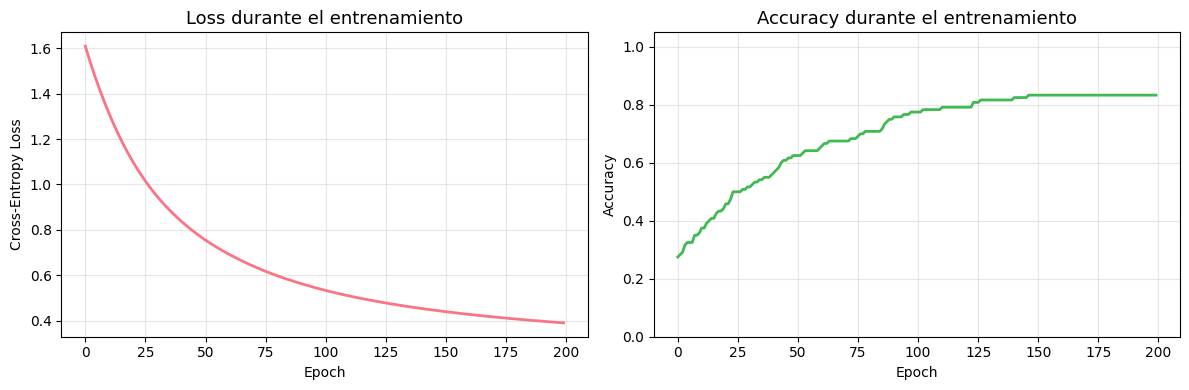


Accuracy en test: 80.00%


In [6]:
# --- Gráficas de entrenamiento ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color='#F97583', linewidth=2)
ax1.set_title('Loss durante el entrenamiento', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(accuracies, color='#3FB950', linewidth=2)
ax2.set_title('Accuracy durante el entrenamiento', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Evaluar en test ---
Z1_test = X_test @ W1.T + b1
A1_test = relu(Z1_test)
Z2_test = A1_test @ W2.T + b2
A2_test = softmax(Z2_test)

test_acc = np.mean(np.argmax(A2_test, axis=1) == np.argmax(y_test, axis=1))
print(f"\nAccuracy en test: {test_acc:.2%}")

---

## Equivalente en TensorFlow

Todo lo que hicimos en ~50 líneas de NumPy, TensorFlow lo resuelve así:

In [7]:
import tensorflow as tf

# Mismos datos
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', kernel_initializer='he_normal', input_shape=(4,)),
    tf.keras.layers.Dense(3, activation='softmax', kernel_initializer='he_normal')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Users/joselandero/Desktop/Proyectos/Redes_Neuronales/env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=120,  # un solo batch como nuestro NumPy
    verbose=0
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (TF): {test_acc:.2%}")

Test Accuracy (TF): 80.00%


---

## Reflexión final

Este notebook cubrió el ciclo completo que repite una red neuronal en cada paso de entrenamiento:

1. **Forward Propagation** — el dato fluye hacia adelante: $Z = XW^T + b$, luego $A = f(Z)$, capa por capa hasta obtener $\hat{y}$
2. **Loss** — medimos el error: MSE para regresión, cross-entropy para clasificación
3. **Backpropagation** — propagamos el error hacia atrás usando la regla de la cadena para obtener $\frac{\partial \mathcal{L}}{\partial W}$ de cada capa
4. **Optimización** — actualizamos los pesos: $W \leftarrow W - \eta \nabla W$

TensorFlow encapsula estos 4 pasos en `model.fit()`, pero por debajo ejecuta exactamente la misma matemática.

### Siguiente: Regularización
Ahora que entendemos cómo aprende una red, el siguiente tema es **cómo evitar que memorice los datos** en vez de generalizar — overfitting, dropout, L1/L2, y batch normalization.